<a href="https://colab.research.google.com/github/ankitag86/springboard/blob/main/Deep_Learning_with_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Keras is an open source deep learning library that enables fast experimentation with neural networks. It runs on top of other frameworks like Tensorflow, Theano or CNTK.

Why use Keras?
So, why use Keras instead of other low-level libraries like TensorFlow? Well, with Keras you can build industry-ready models in no time, with much less code than Theano, as we saw before, and a higher abstraction than that offered by TensorFlow. This allows for quickly and easily checking if a neural network will get your problems solved. In addition, you can build any architecture you can imagine, from simple networks to more complex ones like auto-encoders, convolutional or recurrent neural networks.

Neural networks are good feature extractors, since they learn the best way to make sense of unstructured data.
Unstructured data is data that is not easily put into a table. For instance, sound, Videos, images, etc. It's also the type of data where performing feature engineering can be more challenging, that's why leaving this task to neural networks is a good idea.

You will build a network that takes two numbers as an input, passes them through a hidden layer of 10 neurons, and finally outputs a single non-constrained number.

A non-constrained output can be obtained by avoiding setting an activation function in the output layer. This is useful for problems like regression, when we want our output to be able to take any non-constrained value.

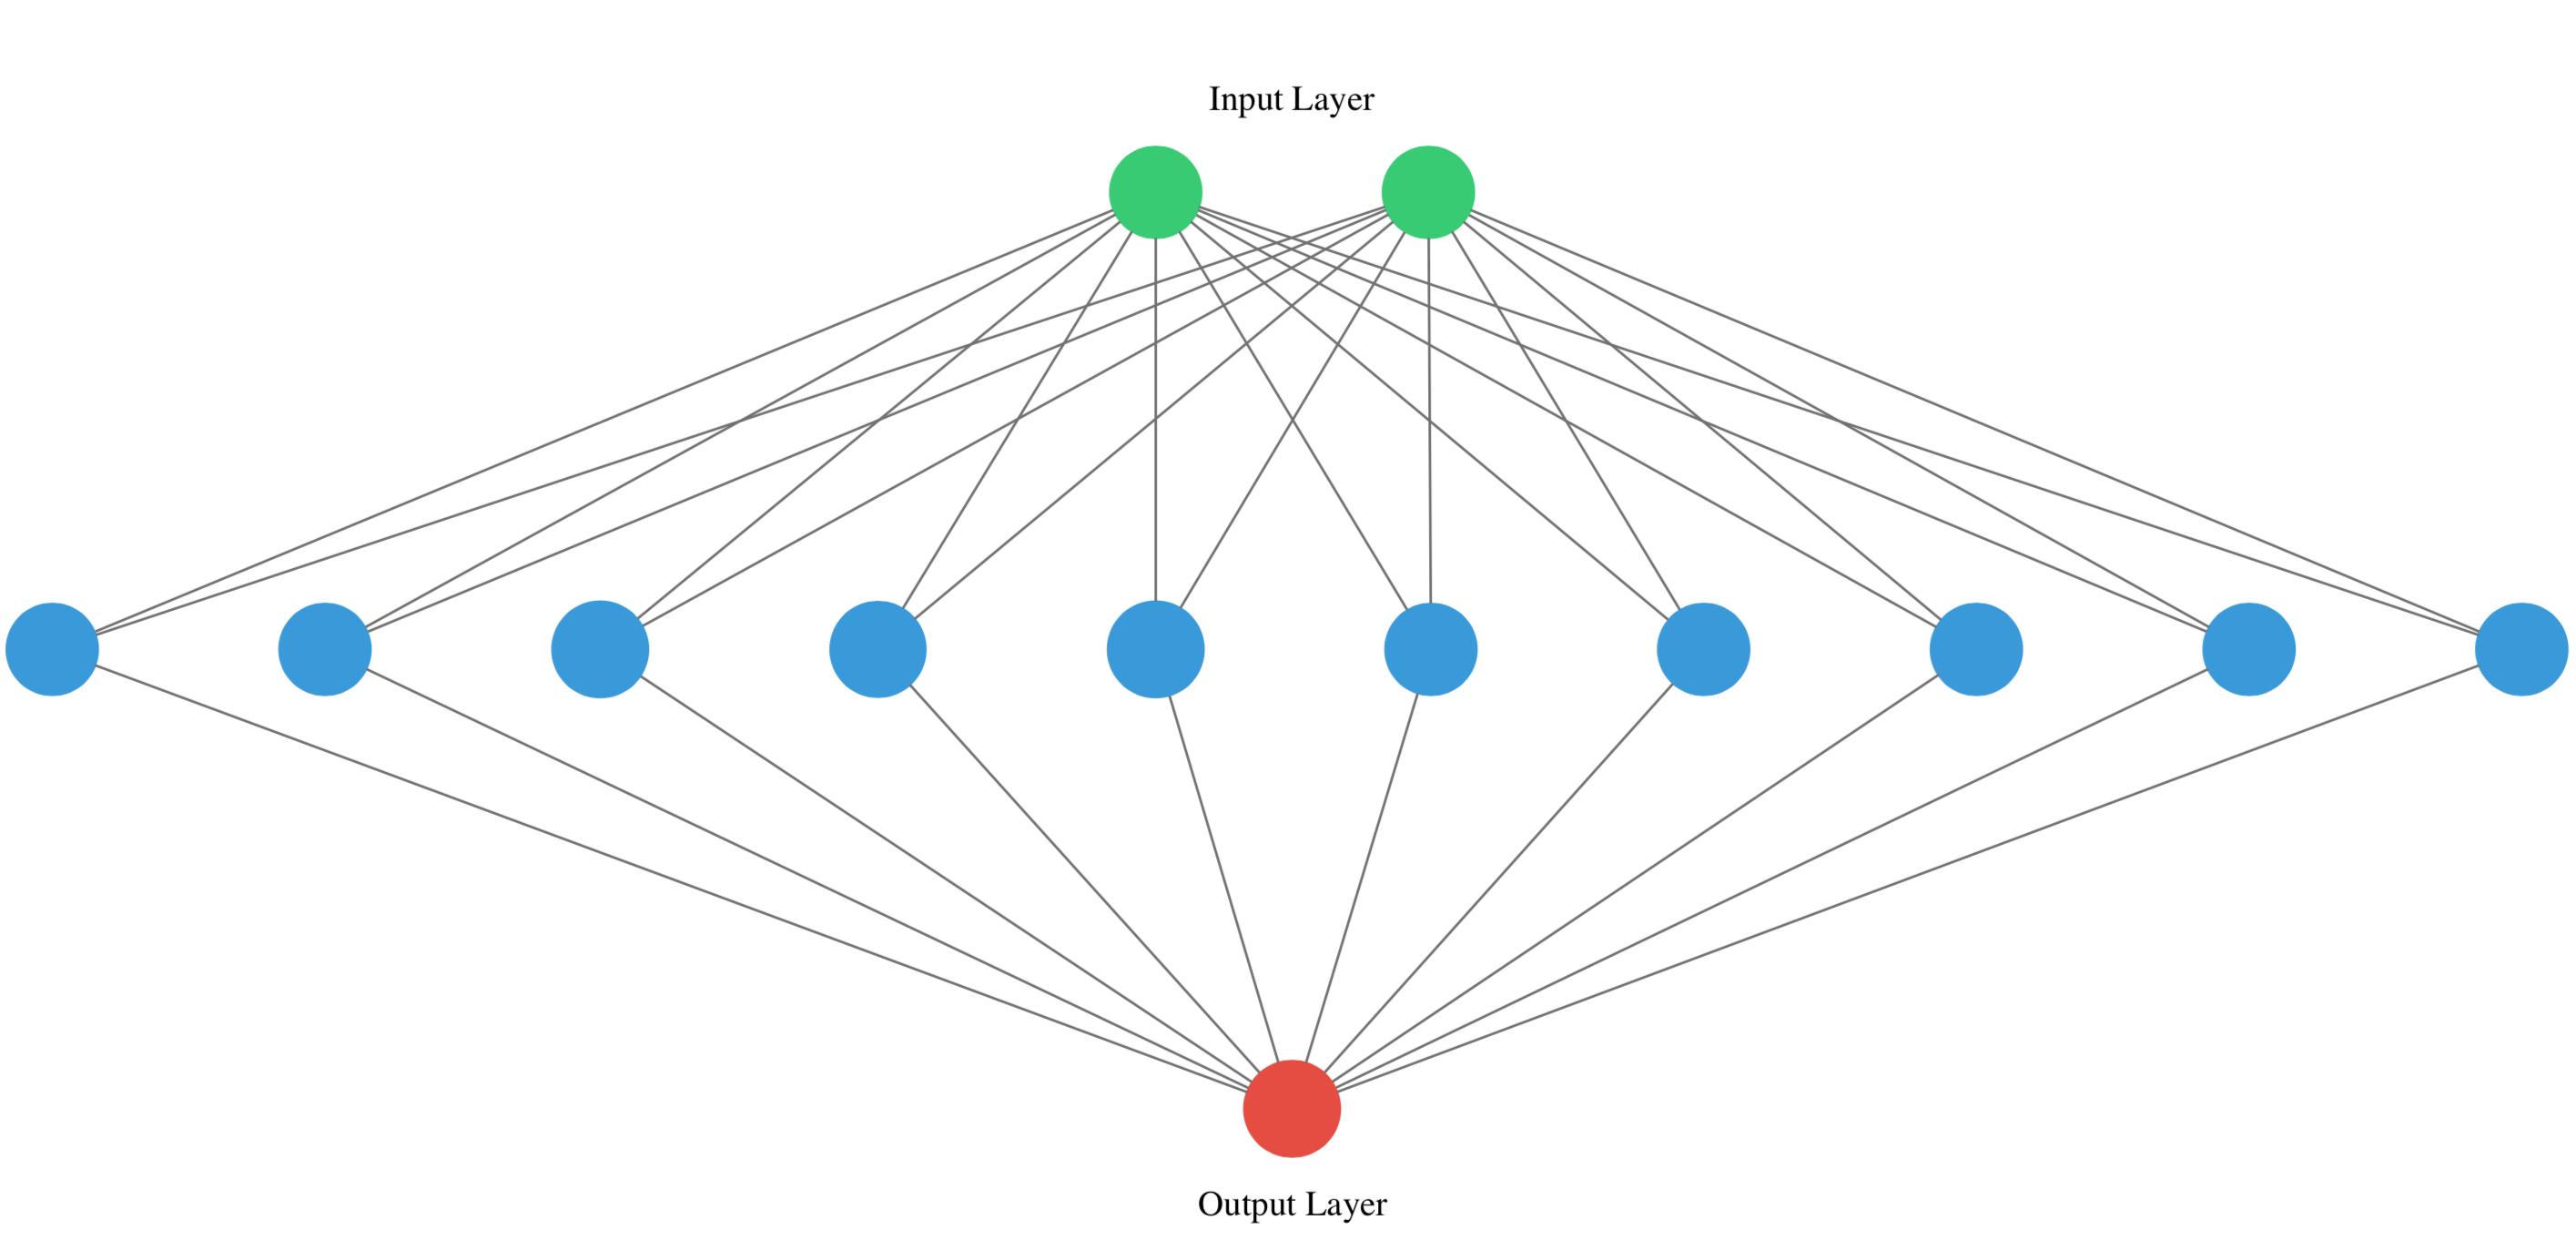


Instructions
Import the Sequential model from tensorflow.keras.models and the Denselayer from tensorflow.keras.layers.
Create an instance of the Sequential model.
Add a 10-neuron hidden Dense layer with an input_shape of two neurons.
Add a final 1-neuron output layer and summarize your model with summary().

In [1]:
# Import the Sequential model and Dense layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a Sequential model
model = Sequential()

# Add an input layer and a hidden layer with 10 neurons
model.add(Dense(10, input_shape=(2,), activation="relu"))

# Add a 1-neuron output layer
model.add(Dense(1))

# Summarise your model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

Exploring dollar bills
You will practice building classification models in Keras with the Banknote Authentication dataset.

Your goal is to distinguish between real and fake dollar bills. In order to do this, the dataset comes with 4 features: variance,skewness,kurtosis and entropy. These features are calculated by applying mathematical operations over the dollar bill images. The labels are found in the dataframe's class column.

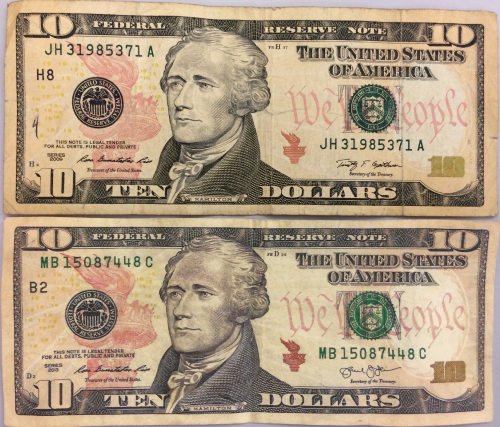

A pandas DataFrame named banknotes is ready to use, let's do some data exploration!

Instructions:
Import seaborn as sns.
Use seaborn's pairplot() on banknotes and set hue to be the name of the column containing the labels.
Generate descriptive statistics for the banknotes authentication data.
Count the number of observations per label with .value_counts().

In [ ]:
# Import seaborn
import seaborn as sns

# Use pairplot and set the hue to be our class column
sns.pairplot(banknotes, hue="class")

# Show the plot
plt.show()

# Describe the data
print('Dataset stats: \n', banknotes.describe())

# Count the number of observations per class
print('Observations per class: \n', banknotes['class'].value_counts())


<script.py> output:
    Dataset stats:
            variance  skewness  curtosis  entropy
    count    96.000    96.000    96.000   96.000
    mean     -0.058    -0.103     0.230    0.081
    std       1.045     1.059     1.129    0.976
    min      -2.085    -2.622    -1.482   -3.034
    25%      -0.839    -0.916    -0.415   -0.263
    50%      -0.027    -0.038    -0.034    0.395
    75%       0.871     0.814     0.979    0.745
    max       1.869     1.634     3.759    1.343
    Observations per class:
     real    53
    fake    43
    Name: class, dtype: int64


<script.py> output:
    Dataset stats:
            variance  skewness  curtosis  entropy
    count    96.000    96.000    96.000   96.000
    mean     -0.058    -0.103     0.230    0.081
    std       1.045     1.059     1.129    0.976
    min      -2.085    -2.622    -1.482   -3.034
    25%      -0.839    -0.916    -0.415   -0.263
    50%      -0.027    -0.038    -0.034    0.395
    75%       0.871     0.814     0.979    0.745
    max       1.869     1.634     3.759    1.343
    Observations per class:
     real    53
    fake    43
    Name: class, dtype: int64




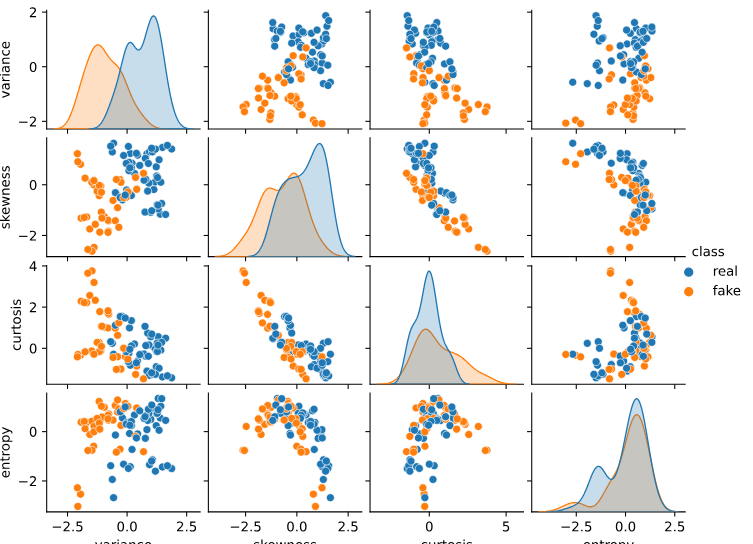

A binary classification model
Now that you know what the Banknote Authentication dataset looks like, we'll build a simple model to distinguish between real and fake bills.

You will perform binary classification by using a single neuron as an output. The input layer will have 4 neurons since we have 4 features in our dataset. The model's output will be a value constrained between 0 and 1.

We will interpret this output number as the probability of our input variables coming from a fake dollar bill, with 1 meaning we are certain it's a fake bill.

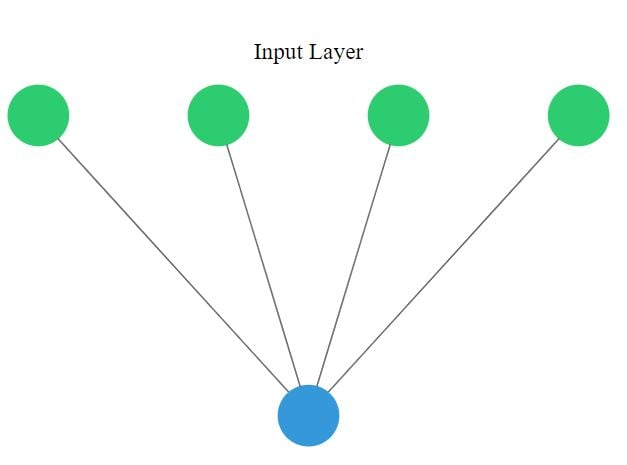

Instructions:

Import the Sequential model and Dense layer from tensorflow.keras.
Create a sequential model.
Add a 4 neuron input layer with the input_shape parameter and a 1 neuron output layer with sigmoid activation.
Compile your model using sgd as an optimizer.

In [3]:
# Import the sequential model and dense layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a sequential model
model = Sequential()

# Add a dense layer
model.add(Dense(1, input_shape=(4,), activation='sigmoid'))

# Compile your model
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Display a summary of your model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

Is this dollar bill fake ?
You are now ready to train your model and check how well it performs when classifying new bills! The dataset has already been partitioned into features: X_train & X_test, and labels: y_train & y_test.

Instructions

Train your model for 20 epochs calling .fit(), passing in the training data.
Check your model accuracy using the .evaluate() method on the test data.
Print accuracy.

In [ ]:
# Train your model for 20 epochs
model.fit(X_train, y_train, epochs = 20)

# Evaluate your model accuracy on the test set
accuracy = model.evaluate(X_test, y_test)[1]

# Print accuracy
print('Accuracy:', accuracy)

<script.py> output:
Epoch 1/20

 1/30 [>.............................] - ETA: 6s - loss: 0.4936 - accuracy: 0.7812
30/30 [==============================] - 0s 621us/step - loss: 0.7107 - accuracy: 0.5760
Epoch 2/20

 1/30 [>.............................] - ETA: 0s - loss: 0.6594 - accuracy: 0.5938
30/30 [==============================] - 0s 568us/step - loss: 0.6337 - accuracy: 0.6250
Epoch 3/20

 1/30 [>.............................] - ETA: 0s - loss: 0.6039 - accuracy: 0.7188
30/30 [==============================] - 0s 684us/step - loss: 0.5741 - accuracy: 0.6896
Epoch 4/20

Accuracy: 0.9029126167297363

**Multi-class classification**

Throwing darts- Identifying who threw which dart in a game of darts is a good example of a multi-class classification problem. Each dart can only be thrown by one competitor. And that means our classes are mutually exclusive since no dart can be thrown by two different competitors simultaneously.


A multi-class model
You're going to build a model that predicts who threw which dart only based on where that dart landed! (That is the dart's x and y coordinates on the board.)

This problem is a multi-class classification problem since each dart can only be thrown by one of 4 competitors. So classes/labels are mutually exclusive, and therefore we can build a neuron with as many output as competitors and use the softmax activation function to achieve a total sum of probabilities of 1 over all competitors.

The Sequential model and Dense layers are already imported for you to use.

Instructions

Instantiate a Sequential model.
Add 3 dense layers of 128, 64 and 32 neurons each.
Add a final dense layer with as many neurons as competitors.
Compile your model using categorical_crossentropy loss.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Instantiate a sequential model
model = Sequential()

# Add 3 dense layers of 128, 64 and 32 neurons each
model.add(Dense(128, input_shape=(2,), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Add a dense layer with as many neurons as competitors
model.add(Dense(4, activation='softmax'))

# Compile your model using categorical_crossentropy loss
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

**Prepare your dataset**
In the console you can check that your labels, darts.competitor are not yet in a format to be understood by your network. They contain the names of the competitors as strings. You will first turn these competitors into unique numbers,then use the to_categorical() function from keras.utils to turn these numbers into their one-hot encoded representation.

This is useful for multi-class classification problems, since there are as many output neurons as classes and for every observation in our dataset we just want one of the neurons to be activated.

The dart's dataset is loaded as darts. Pandas is imported as pd. Let's prepare this dataset!

Instructions

Use the Categorical() method from pandas to transform the competitor column.
Assign a number to each competitor using the cat.codes attribute from the competitor column.

In [ ]:
# Transform into a categorical variable
darts.competitor = pd.Categorical(darts.competitor)

# Assign a number to each category (label encoding)
darts.competitor = darts.competitor.cat.codes

# Print the label encoded competitors
print('Label encoded competitors: \n',darts.competitor.head())

<script.py> output:
Label encoded competitors:
 0    2
1    3
2    1
3    0
4    2
Name: competitor, dtype: int8

**Training on dart throwers**

Your model is now ready, just as your dataset. It's time to train!

The coordinates features and competitors labels you just transformed have been partitioned into coord_train,coord_test and competitors_train,competitors_test.

Your model is also loaded. Feel free to visualize your training data or model.summary() in the console.

Let's find out who threw which dart just by looking at the board!

Instructions

Train your model on the training data for 200 epochs.
Evaluate your model accuracy on the test data.

In [ ]:
# Fit your model to the training data for 200 epochs
model.fit(coord_train,competitors_train,epochs=200)

# Evaluate your model accuracy on the test data
accuracy = model.evaluate(coord_test, competitors_test)[1]

# Print accuracy
print('Accuracy:', accuracy)

**Multi-label classification**

Multi-class and Multi-label - They both deal with predicting classes, but in multi-label classification, a single input can be assigned to more than one class.

An irrigation machine

Let's tackle a new problem. A farm field has an array of 20 sensors distributed along 3 crop fields. These sensors measure, among other things, the humidity of the soil, radiation of the sun, etc. Your task is to use the combination of measurements from these sensors to decide which parcels to water, given each parcel has different environmental requirements.

An irrigation machine
Each sensor measures an integer value between 0 and 13 volts. Parcels can be represented as one-hot encoded vectors of length 3, where each index is one of the parcels. Parcels can be watered simultaneously.

Instructions

Instantiate a Sequential() model.
Add a hidden layer of 64 neurons with as many input neurons as there are sensors and relu activation.
Add an output layer with as many neurons as parcels and sigmoidactivation.
Compile your model with the adam optimizer and binary_crossentropy loss.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Instantiate a Sequential model
model = Sequential()

# Add a hidden layer of 64 neurons and a 20 neuron's input
model.add(Dense(64, input_shape=(20,),activation='relu'))

# Add an output layer of 3 neurons with sigmoid activation
model.add(Dense(3, activation='sigmoid'))

# Compile your model with binary crossentropy loss
model.compile(optimizer='adam',
           loss = 'binary_crossentropy',
           metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,539 (6.01 KB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 0 (0.00 B)

Training with multiple labels

An output of your multi-label model could look like this: [0.76 , 0.99 , 0.66 ]. If we round up probabilities higher than 0.5, this observation will be classified as containing all 3 possible labels [1,1,1]. For this particular problem, this would mean watering all 3 parcels in your farm is the right thing to do, according to the network, given the input sensor measurements.

You will now train and predict with the model you just built. sensors_train, parcels_train, sensors_test and parcels_test are already loaded for you to use.

Let's see how well your intelligent machine performs!

Instructions

Train the model for 100 epochs using a validation_split of 0.2.
Predict with your model using the test data.
Round up your preds with np.round().
Evaluate your model's accuracy on the test data.

In [ ]:
# Train for 100 epochs using a validation split of 0.2
model.fit(sensors_train, parcels_train, epochs = 100, validation_split = 0.2)

# Predict on sensors_test and round up the predictions
preds = model.predict(sensors_test)
preds_rounded = np.round(preds)

# Print rounded preds
print('Rounded Predictions: \n', preds_rounded)

# Evaluate your model's accuracy on the test data
accuracy = model.evaluate(sensors_test, parcels_test)[1]

# Print accuracy
print('Accuracy:', accuracy)

**Keras callbacks**

a keras callback is a block of code that gets executed after each epoch during training or after the training is finished. They are useful to store metrics as the model trains and to make decisions as the training goes by.

Callbacks in Kera -
1. History: compare training and validation metrics
2. EarlyStopping: Early stopping a model can solve the overfitting problem
3. ModelCheckpoint: allows us to save our model as it trains



**The history callback**
The history callback is returned by default every time you train a model with the .fit() method. To access these metrics you can access the history dictionary parameter inside the returned h_callback object with the corresponding keys.

The irrigation machine model you built in the previous lesson is loaded for you to train, along with its features and labels now loaded as X_train, y_train, X_test, y_test. This time you will store the model's historycallback and use the validation_data parameter as it trains.

You will plot the results stored in history with plot_accuracy() and plot_loss(), two simple matplotlib functions. You can check their code in the console by pasting show_code(plot_loss).

Let's see the behind the scenes of our training!

Instructions

Train your model on X_train and y_train, validate each epoch on X_test and y_test.
Use plot_lossextracting lossand val_loss from h_callback.
Use plot_accuracyextracting accuracyand val_accuracy from h_callback.

In [ ]:
# Train your model and save its history
h_callback = model.fit(X_train, y_train, epochs = 25,
               validation_data=(X_test, y_test))

# Plot train vs test loss during training
plot_loss(h_callback.history['loss'], h_callback.history['val_loss'])

# Plot train vs test accuracy during training
plot_accuracy(h_callback.history['accuracy'], h_callback.history['val_accuracy'])

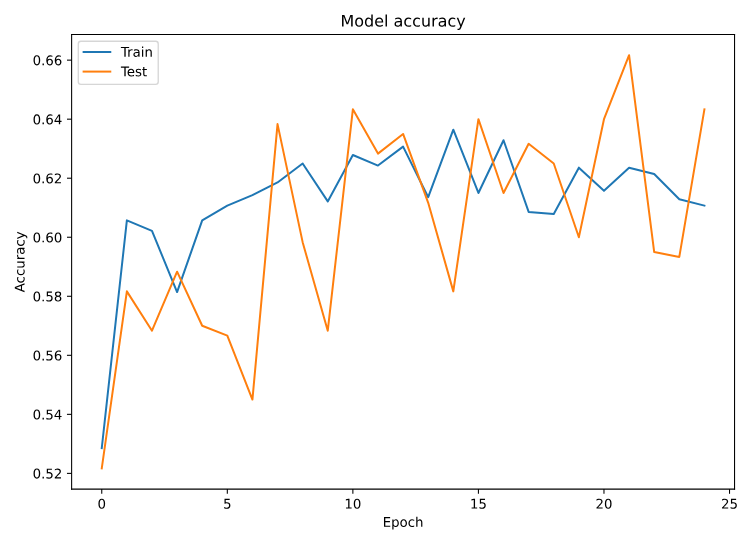

**Early stopping your model**
The early stopping callback is useful since it allows for you to stop the model training if it no longer improves after a given number of epochs. To make use of this functionality you need to pass the callback inside a list to the model's callback parameter in the .fit() method.

The model you built to detect fake dollar bills is loaded for you to train, this time with early stopping. X_train, y_train, X_test and y_test are also available for your use.

Instructions

Import the EarlyStoppingcallback from tensorflow.keras.callbacks.
Define a callback, monitor 'val_accuracy' with a patience of 5 epochs.
Train your model using the early stopping callback.

In [ ]:
# Import the early stopping callback
from tensorflow.keras.callbacks import EarlyStopping

# Define a callback to monitor val_accuracy
monitor_val_acc = EarlyStopping(monitor='val_accuracy',
                       patience=5)

# Train your model using the early stopping callback
model.fit(X_train, y_train,
           epochs=1000, validation_data=(X_test , y_test),
           callbacks= [monitor_val_acc])

**A combination of callbacks**

Deep learning models can take a long time to train, especially when you move to deeper architectures and bigger datasets. Saving your model every time it improves as well as stopping it when it no longer does allows you to worry less about choosing the number of epochs to train for. You can also restore a saved model anytime and resume training where you left it.

The model training and validation data are available in your workspace as X_train, X_test, y_train, and y_test.

Use the EarlyStopping() and the ModelCheckpoint() callbacks so that you can go eat a jar of cookies while you leave your computer to work!

Instructions

Import both the EarlyStopping and ModelCheckpoint callbacks from tensorflow.keras.
Create monitor_val_acc as an EarlyStopping callback that will monitor 'val_accuracy', with a patience of 3 epochs.
Create model_checkpoint as a ModelCheckpointcallback, save the best model as best_banknote_model.hdf5.
Fit your model providing a list with the defined callbacks and X_test and y_test as validation data.

In [ ]:
# Import the EarlyStopping and ModelCheckpoint callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stop on validation accuracy
monitor_val_acc = EarlyStopping(monitor = 'val_accuracy', patience = 3)

# Save the best model as best_banknote_model.hdf5
model_checkpoint = ModelCheckpoint('best_banknote_model.hdf5', save_best_only = True)

# Fit your model for a stupid amount of epochs
h_callback = model.fit(X_train, y_train,
                    epochs = 1000000000000,
                    callbacks = [monitor_val_acc, model_checkpoint],
                    validation_data = (X_test, y_test))

**Improving Your Model Performance**

**Learning the digits**

You're going to build a model on the digits dataset, a sample dataset that comes pre-loaded with scikit learn. The digits dataset consist of 8x8 pixel handwritten digits from 0 to 9:


You want to distinguish between each of the 10 possible digits given an image, so we are dealing with multi-class classification.
The dataset has already been partitioned into X_train, y_train, X_test, and y_test, using 30% of the data as testing data. The labels are already one-hot encoded vectors, so you don't need to use Keras to_categorical() function.

Let's build this new model!

Instructions

Add a Dense layer of 16 neurons with relu activation and an input_shape that takes the total number of pixels of the 8x8 digit image.
Add a Dense layer with 10 outputs and softmax activation.
Compile your model with adam, categorical_crossentropy, and accuracy metrics.
Make sure your model works by predicting on X_train.

In [ ]:
# Instantiate a Sequential model
model = Sequential()

# Input and hidden layer with input_shape, 16 neurons, and relu
model.add(Dense(16, input_shape = (64,), activation = 'relu'))

# Output layer with 10 neurons (one per digit) and softmax
model.add(Dense(10))

# Compile your model
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

# Test if your model is well assembled by predicting before training
print(model.predict(X_train))

<script.py> output:
[[ -4.2465887 -10.348243    4.860893  ...  -8.349369    4.719602
    8.654853 ]
 [ -8.902591   -2.1626666   8.841244  ...  -2.4165294   6.065701
    7.325094 ]
 [ -8.921554    1.6125393   9.781737  ...  -8.820707    8.344074
    3.7130775]
 ...
 [ -3.9814715  -1.6849985   6.087055  ... -14.787571    3.9193058
    2.019571 ]
 [ -1.0528374  -1.2427757   8.693664  ...  -8.28962     0.9657526
    5.923299 ]
 [ -0.9828749  -4.7043447   5.690707  ... -13.216734    7.548212
   15.822845 ]]

Is the model overfitting?

Let's train the model you just built and plot its learning curve to check out if it's overfitting! You can make use of the loaded function plot_loss() to plot training loss against validation loss, you can get both from the history callback.

If you want to inspect the plot_loss() function code, paste this in the console: show_code(plot_loss)

Instructions 1/2

Train your model for 60 epochs, using X_test and y_test as validation data.
Use plot_loss() passing loss and val_loss as extracted from the history attribute of the h_callback object.

In [ ]:
# Train your model for 60 epochs, using X_test and y_test as validation data
h_callback = model.fit(X_train, y_train, epochs = 60, validation_data = (X_test, y_test), verbose=0)

# Extract from the h_callback object loss and val_loss to plot the learning curve
plot_loss(h_callback.history['loss'], h_callback.history['val_loss'])

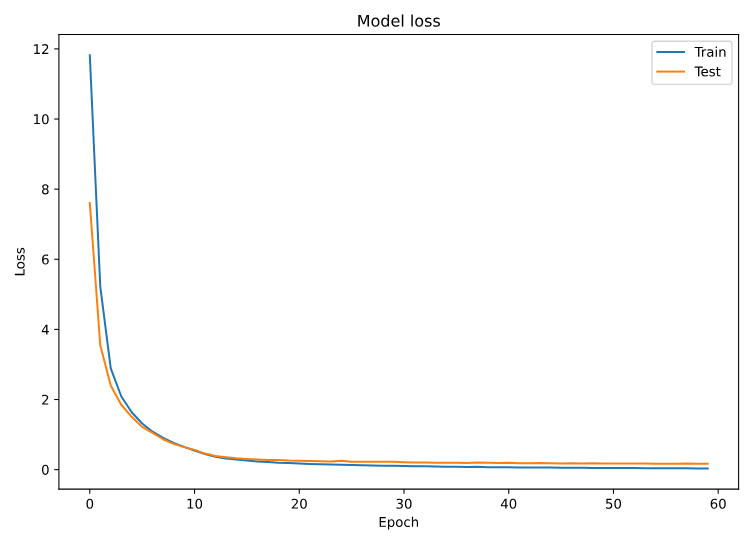

**Hyperparameter tuning - Keras**

Preparing a model for tuning
Let's tune the hyperparameters of a binary classification model that does well classifying the breast cancer dataset.

You've seen that the first step to turn a model into a sklearn estimator is to build a function that creates it. The definition of this function is important since hyperparameter tuning is carried out by varying the arguments your function receives.

Build a simple create_model() function that receives both a learning rate and an activation function as arguments. The Adam optimizer has been imported as an object from tensorflow.keras.optimizers so that you can also change its learning rate parameter.

Instructions:

Set the learning rate of the Adam optimizer object to the one passed in the arguments.
Set the hidden layers activations to the one passed in the arguments.
Pass the optimizer and the binary cross-entropy loss to the .compile() method.

In [ ]:
# Creates a model given an activation and learning rate
def create_model(learning_rate, activation):

  	# Create an Adam optimizer with the given learning rate
  	opt = Adam(lr = learning_rate)

  	# Create your binary classification model
  	model = Sequential()
  	model.add(Dense(128, input_shape = (30,), activation = activation))
  	model.add(Dense(256, activation = activation))
  	model.add(Dense(1, activation = 'sigmoid'))

  	# Compile your model with your optimizer, loss, and metrics
  	model.compile(optimizer = opt, loss = 'binary_crossentropy', metrics = ['accuracy'])
  	return model

Tuning the model parameters

It's time to try out different parameters on your model and see how well it performs!

The create_model() function you built in the previous exercise is ready for you to use.

Since fitting the RandomizedSearchCV object would take too long, the results you'd get are printed in the show_results() function. You could try random_search.fit(X,y) in the console yourself to check it does work after you have built everything else, but you will probably timeout the exercise (so copy your code first if you try this or you can lose your progress!).

You don't need to use the optional epochs and batch_size parameters when building your KerasClassifier object since you are passing them as params to the random search and this works already.

Instructions

Import KerasClassifier from tensorflow.keras scikit_learn wrappers.
Use your create_model function when instantiating your KerasClassifier.
Set 'relu' and 'tanh' as activation, 32, 128, and 256 as batch_size, 50, 100, and 200 epochs, and learning_rate of 0.1, 0.01, and 0.001.
Pass your converted model and the chosen params as you build your RandomizedSearchCV object.

In [ ]:
# Import KerasClassifier from tensorflow.keras scikit learn wrappers
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Create a KerasClassifier
model = KerasClassifier(build_fn = create_model)

# Define the parameters to try out
params = {'activation': ['relu', 'tanh'], 'batch_size': [32, 128, 256],
          'epochs': [50, 100, 200], 'learning_rate': [0.1, 0.01, 0.001]}

# Create a randomize search cv object passing in the parameters to try
random_search = RandomizedSearchCV(model, param_distributions = params, cv = KFold(3))

# Running random_search.fit(X,y) would start the search,but it takes too long!
show_results()

Training with cross-validation

Time to train your model with the best parameters found: 0.001 for the learning rate, 50 epochs, a 128 batch_size and relu activations.

The create_model() function from the previous exercise is ready for you to use. X and y are loaded as features and labels.

Use the best values found for your model when creating your KerasClassifier object so that they are used when performing cross_validation.

End this chapter by training an awesome tuned model on the breast cancer dataset!

Instructions

Import KerasClassifier from tensorflow.keras scikit_learn wrappers.
Create a KerasClassifier object providing the best parameters found.
Pass your model, features and labels to cross_val_score to perform cross-validation with 3 folds

In [ ]:
# Import KerasClassifier from tensorflow.keras wrappers
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Create a KerasClassifier
model = KerasClassifier(build_fn = create_model(learning_rate = 0.001, activation = 'relu'), epochs = 50,
             batch_size = 128, verbose = 0)

# Calculate the accuracy score for each fold
kfolds = cross_val_score(model, X, y, cv = 3)


# Print the mean accuracy
print('The mean accuracy was:', kfolds.mean())

# Print the accuracy standard deviation
print('With a standard deviation of:', kfolds.std())


<script.py> output: The mean accuracy was: 0.9718834066666666
With a standard deviation of: 0.002448915612216046

**Text prediction with LSTMs**

During the following exercises you will build a toy LSTM model that is able to predict the next word using a small text dataset. This dataset consist of cleaned quotes from the The Lord of the Ring movies. You can find them in the text variable.

You will turn this text into sequences of length 4 and make use of the Keras Tokenizer to prepare the features and labels for your model!

The Keras Tokenizer is already imported for you to use. It assigns a unique number to each unique word, and stores the mappings in a dictionary. This is important since the model deals with numbers but we later will want to decode the output numbers back into words.

Instructions

Split the text into an array of words using .split().
Make sentences of 4 words each, moving one word at a time.
Instantiate a Tokenizer(), then fit it on the sentences with .fit_on_texts().
Turn sentences into a sequence of numbers calling .texts_to_sequences().

In [ ]:
# Split text into an array of words
words = text.split()

# Make sentences of 4 words each, moving one word at a time
sentences = []
for i in range(4, len(words)):
  sentences.append(' '.join(words[i-4:i]))

# Instantiate a Tokenizer, then fit it on the sentences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

# Turn sentences into a sequence of numbers
sequences = tokenizer.texts_to_sequences(sentences)
print("Sentences: \n {} \n Sequences: \n {}".format(sentences[:5],sequences[:5]))


You're working with this small chunk of The Lord of The Ring quotes stored in the text variable:
================================================================================================
 It is not the strength of the body but the strength of the spirit.
 It is useless to meet revenge with revenge it will heal nothing.
 Even the smallest person can change the course of history.
 All we have to decide is what to do with the time that is given us.
 The burned hand teaches best. After that, advice about fire goes to the heart.

<script.py> output:
    Sentences:
     ['it is not the', 'is not the strength', 'not the strength of', 'the strength of the', 'strength of the body']
     Sequences:
     [[5, 2, 42, 1], [2, 42, 1, 6], [42, 1, 6, 4], [1, 6, 4, 1], [6, 4, 1, 10]]

**Build your LSTM model**

You've already prepared your sequences of text. It's time to build your LSTM model!

Remember your sequences had 4 words each, your model will be trained on the first three words of each sequence, predicting the 4th one. You are going to use an Embedding layer that will essentially learn to turn words into meaningful vectors. These vectors will then be passed to a simple LSTM layer. Our output is a Dense layer with as many neurons as words in the vocabulary and softmax activation. This is because we want to obtain the highest probable next word out of all possible words.

The size of the vocabulary of words (the unique number of words) is stored in vocab_size.

Instructions

Import the Embedding, LSTM and Dense layer from tensorflow.keras layers.
Add an Embedding() layer of the vocabulary size, that will turn words into 8 number vectors and receive sequences of length 3.
Add a 32 neuron LSTM() layer.
Add a hidden Dense() layer of 32 neurons and an output layer of vocab_size neurons with softmax.

In [ ]:
# Import the Embedding, LSTM and Dense layer
from tensorflow.keras.layers import Dense, Embedding, LSTM

model = Sequential()

# Add an Embedding layer with the right parameters
model.add(Embedding(input_dim = vocab_size, input_length = 3, output_dim = 8, ))

# Add a 32 unit LSTM layer
model.add(LSTM(32))

# Add a hidden Dense layer of 32 units and an output layer of vocab_size with softmax
model.add(Dense(32, activation='relu'))
model.add(Dense(vocab_size, activation='softmax'))
model.summary()


<script.py> output:
    Model: "sequential"
    _________________________________________________________________
    Layer (type)                 Output Shape              Param #
    =================================================================
    embedding (Embedding)        (None, 3, 8)              352
    _________________________________________________________________
    lstm (LSTM)                  (None, 32)                5248
    _________________________________________________________________
    dense (Dense)                (None, 32)                1056
    _________________________________________________________________
    dense_1 (Dense)              (None, 44)                1452
    =================================================================
    Total params: 8,108
    Trainable params: 8,108
    Non-trainable params: 0
    _________________________________________________________________

**Decode your predictions**

Your LSTM model has already been trained (details in the previous exercise success message) so that you don't have to wait. It's time to define a function that decodes its predictions. The trained model will be passed as a default parameter to this function.

Since you are predicting on a model that uses the softmax function, numpy's argmax() can be used to obtain the index/position representing the most probable next word out of the output vector of probabilities.

The tokenizer you previously created and fitted, is loaded for you. You will be making use of its internal index_word dictionary to turn the model's next word prediction (which is an integer) into the actual written word it represents.

You're very close to experimenting with your model!

Instructions

Use texts_to_sequences() to turn the test_text parameter into a sequence of numbers.
Get the model's next word prediction by passing in test_seq . The index/position representing the word with the highest probability is obtained by calling .argmax(axis=1)[0] on the numpy array of predictions.
Return the word that maps to the prediction using the tokenizer's index_word dictionary.

In [ ]:
def predict_text(test_text, model = model):
  if len(test_text.split()) != 3:
    print('Text input should be 3 words!')
    return False

  # Turn the test_text into a sequence of numbers
  test_seq = tokenizer.texts_to_sequences([test_text])
  test_seq = np.array(test_seq)

  # Use the model passed as a parameter to predict the next word
  pred = model.predict(test_seq).argmax(axis = 1)[0]

  # Return the word that maps to the prediction
  return tokenizer.index_word[pred]

<script.py> output:
  In [1]:'meet revenge with'
  Out[1]:'meet revenge with'